In [1]:
# This notebook will get the true nexus files and the selected events to plot the signal efficiencies

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 
import glob

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *

%matplotlib widget



In [2]:
# Per sample, load time is: 
def LoadFiles(filepath):
    
    files = glob.glob(filepath)
    
    
    parts = []
    for i, f in enumerate(files):
        if i %500 ==0:
            print(f"{i} /", len(files))
        part = pd.read_hdf(f, "MC/particles", columns=["event_id","primary","particle_id", "initial_z", "final_z", "kin_energy"])
        part = part[part.primary == 1]
        parts.append(part)
        # display(parts)
        # break
    
    return pd.concat(parts)



In [3]:


basepath = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ATPC_0nubb/"
nubb_25bar = LoadFiles(f"{basepath}/25bar/nexus/*.h5")
nubb_15bar = LoadFiles(f"{basepath}/15bar/nexus/*.h5")
nubb_10bar = LoadFiles(f"{basepath}/10bar/nexus/*.h5")
nubb_5bar = LoadFiles(f"{basepath}/5bar/nexus/*.h5")
nubb_1bar = LoadFiles(f"{basepath}/1bar/nexus/*.h5")

0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 2996
500 / 2996
1000 / 2996
1500 / 2996
2000 / 2996
2500 / 2996


In [4]:
def CalcAssymetry(df):
    part1 = df[df.particle_id == 1]
    part2 = df[df.particle_id == 2]
    
    return np.abs((part1.kin_energy.values-part2.kin_energy.values)/(part1.kin_energy.values+part2.kin_energy.values))

# ------------------------------------------------------------------------
def CalcEfficiency(n, N):
    efficiency = 0.82*n/N
    error=np.sqrt( (efficiency/N) * (1-efficiency)  )
    return efficiency, error


shifts = np.array([6.2, 3.6, 2.9, 2.5, 2.1])*1000/2.0

# ------------------------------------------------------------------------
# Gets the final z-position of the lowest energy electron
def GetZPos(df, shift):
    idx = df.groupby('event_id')['kin_energy'].idxmin()
    lowest_energy_particles = df.loc[idx]
    return (lowest_energy_particles.final_z + shift)/ (shift*2.0)

def GetZPos2(df, shift):
    part1 = df[df.particle_id == 1]
    return (part1.initial_z + shift)/ (shift*2.0)

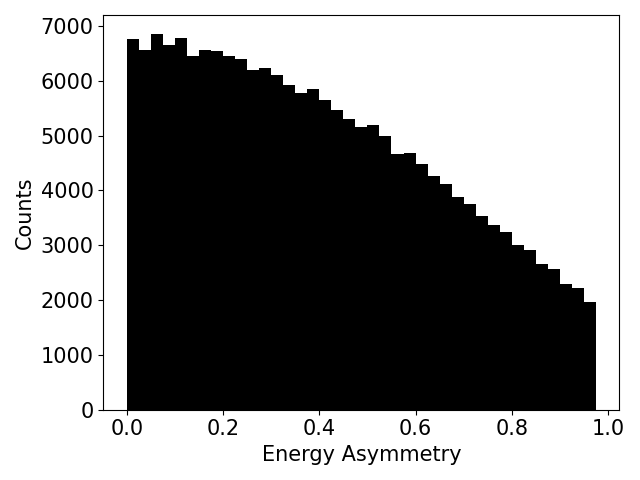

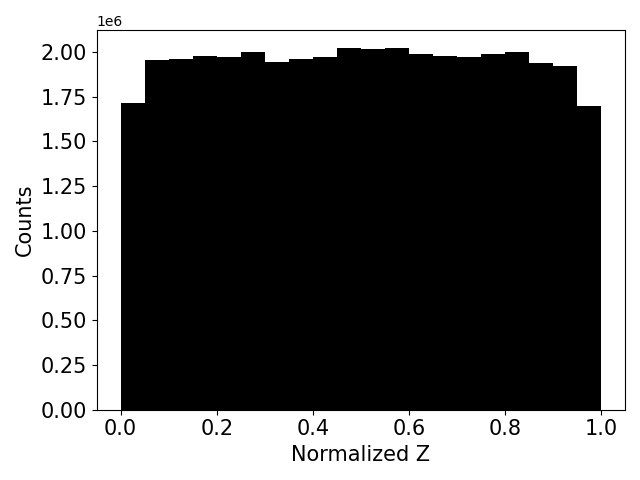

In [5]:
# display(nubb)

plt.figure()

n_gen, bins, _ = plt.hist( CalcAssymetry(nubb_25bar), bins = np.arange(0,1,0.025),color = "k");
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.tight_layout()

plt.figure()
n_gen, bins, _ = plt.hist( GetZPos(nubb_25bar, shifts[4]), bins = np.arange(0,1.05,0.05),color = "k");
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.tight_layout()

In [6]:
print(len(nubb_1bar.event_id.unique()))

192964


Correcting Efficiency by factor  0.876
Correcting Efficiency by factor  0.835
Correcting Efficiency by factor  0.806
Correcting Efficiency by factor  0.74
Correcting Efficiency by factor  0.532
Correcting Efficiency by factor  0.876
Correcting Efficiency by factor  0.835
Correcting Efficiency by factor  0.806
Correcting Efficiency by factor  0.74
Correcting Efficiency by factor  0.532


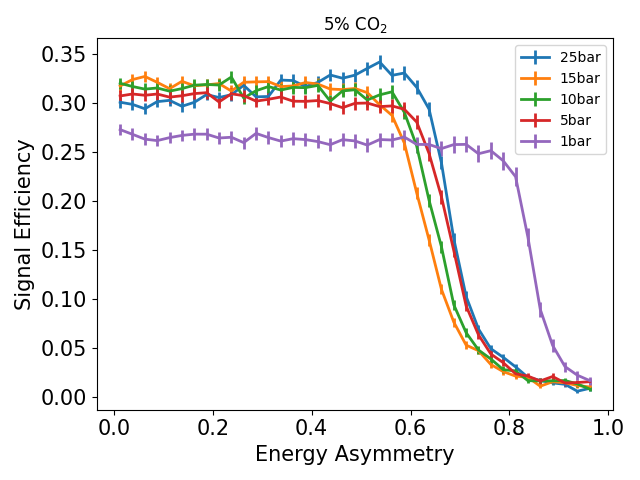

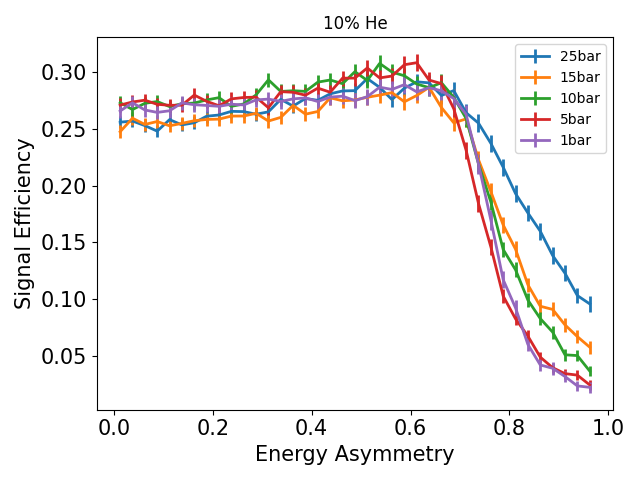

In [7]:
# Load in the event list

def GetAsymmetryHistogram(df, eventlist, pressure):
    
    filt_evid = pd.read_csv(eventlist)
    df_filt = df[df.event_id.isin(filt_evid.event_id.values)]
    
    n_gen, bins = np.histogram( CalcAssymetry(df),      bins = np.arange(0,1,0.025));
    n_sel, _    = np.histogram( CalcAssymetry(df_filt), bins = np.arange(0,1,0.025));
    efficiency, error = CalcEfficiency(n_sel, n_gen)
    
    efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers

nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetAsymmetryHistogram(nubb_25bar, "../eventlists/truestudy/ATPC_0nubb_25bar_5percent.csv", 25)
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetAsymmetryHistogram(nubb_15bar, "../eventlists/truestudy/ATPC_0nubb_15bar_5percent.csv", 15)
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetAsymmetryHistogram(nubb_10bar, "../eventlists/truestudy/ATPC_0nubb_10bar_5percent.csv", 10)
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetAsymmetryHistogram(nubb_5bar, "../eventlists/truestudy/ATPC_0nubb_5bar_5percent.csv", 5)
nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetAsymmetryHistogram(nubb_1bar, "../eventlists/truestudy/ATPC_0nubb_1bar_5percent.csv", 1)

plt.figure()
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_5bar_5percent_bins, nubb_5bar_5percent_eff, yerr=nubb_5bar_5percent_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetAsymmetryHistogram(nubb_25bar, "../eventlists/truestudy/ATPC_0nubb_25bar_0.05percent.csv", 25)
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetAsymmetryHistogram(nubb_15bar, "../eventlists/truestudy/ATPC_0nubb_15bar_0.05percent.csv", 15)
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetAsymmetryHistogram(nubb_10bar, "../eventlists/truestudy/ATPC_0nubb_10bar_0.05percent.csv", 10)
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetAsymmetryHistogram(nubb_5bar, "../eventlists/truestudy/ATPC_0nubb_5bar_0.05percent.csv", 5)
nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetAsymmetryHistogram(nubb_1bar, "../eventlists/truestudy/ATPC_0nubb_1bar_0.05percent.csv", 1)

plt.figure()
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_5bar_He_bins, nubb_5bar_He_eff, yerr=nubb_5bar_He_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_1bar_He_bins, nubb_1bar_He_eff, yerr=nubb_1bar_He_err, linewidth = 2, label = "1bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()


Correcting Efficiency by factor  0.876
Correcting Efficiency by factor  0.835
Correcting Efficiency by factor  0.806
Correcting Efficiency by factor  0.74
Correcting Efficiency by factor  0.532
Correcting Efficiency by factor  0.876
Correcting Efficiency by factor  0.835
Correcting Efficiency by factor  0.806
Correcting Efficiency by factor  0.74
Correcting Efficiency by factor  0.532


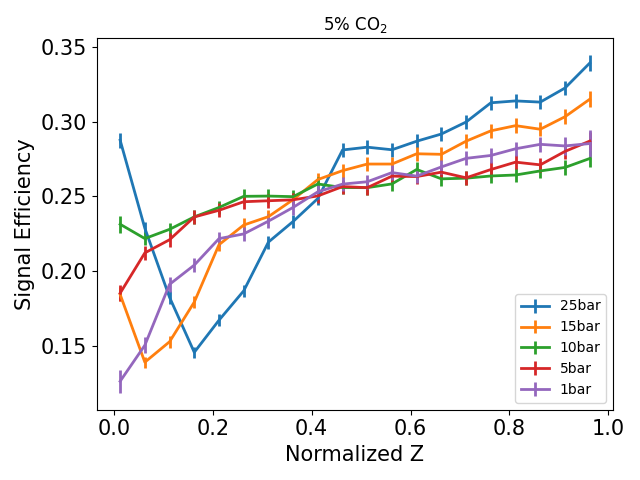

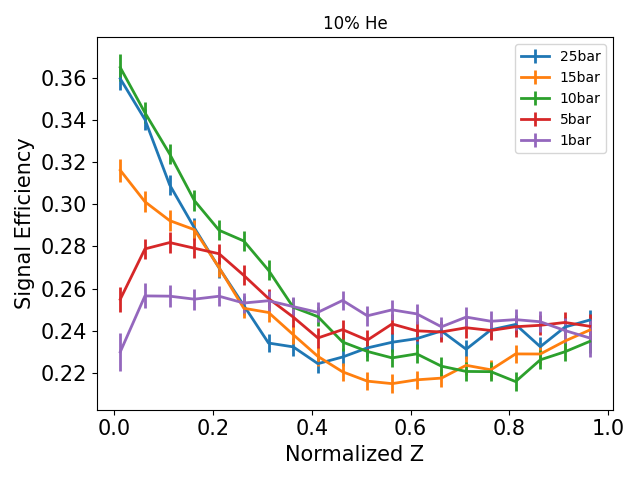

In [8]:
# Load in the event list

def GetZPosHistogram(df, eventlist, shift, pressure):
    
    filt_evid = pd.read_csv(eventlist)
    df_filt = df[df.event_id.isin(filt_evid.event_id.values)]
    
    n_gen, bins = np.histogram( GetZPos2(df, shift), bins = np.arange(0,1.05,0.05));
    n_sel, _    = np.histogram( GetZPos2(df_filt, shift), bins = np.arange(0,1.05,0.05));
    efficiency, error = CalcEfficiency(n_sel, n_gen)
    efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers

nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetZPosHistogram(nubb_25bar, "../eventlists/truestudy/ATPC_0nubb_25bar_5percent.csv", shifts[4], 25)
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetZPosHistogram(nubb_15bar, "../eventlists/truestudy/ATPC_0nubb_15bar_5percent.csv", shifts[3], 15)
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetZPosHistogram(nubb_10bar, "../eventlists/truestudy/ATPC_0nubb_10bar_5percent.csv", shifts[2], 10)
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetZPosHistogram(nubb_5bar, "../eventlists/truestudy/ATPC_0nubb_5bar_5percent.csv", shifts[1], 5)
nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetZPosHistogram(nubb_1bar, "../eventlists/truestudy/ATPC_0nubb_1bar_5percent.csv", shifts[0], 1)

plt.figure()
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_5bar_5percent_bins, nubb_5bar_5percent_eff, yerr=nubb_5bar_5percent_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetZPosHistogram(nubb_25bar, "../eventlists/truestudy/ATPC_0nubb_25bar_0.05percent.csv", shifts[4], 25)
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetZPosHistogram(nubb_15bar, "../eventlists/truestudy/ATPC_0nubb_15bar_0.05percent.csv", shifts[3], 15)
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetZPosHistogram(nubb_10bar, "../eventlists/truestudy/ATPC_0nubb_10bar_0.05percent.csv", shifts[2], 10)
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetZPosHistogram(nubb_5bar, "../eventlists/truestudy/ATPC_0nubb_5bar_0.05percent.csv", shifts[1], 5)
nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetZPosHistogram(nubb_1bar, "../eventlists/truestudy/ATPC_0nubb_1bar_0.05percent.csv", shifts[0], 1)

plt.figure()
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_5bar_He_bins, nubb_5bar_He_eff, yerr=nubb_5bar_He_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_1bar_He_bins, nubb_1bar_He_eff, yerr=nubb_1bar_He_err, linewidth = 2, label = "1bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()


In [9]:
def GetAsymmetryHistogram(df, eventlist, pressure):
    
    filt_evid = pd.read_csv(eventlist)
    df_filt = df[df.event_id.isin(filt_evid.event_id.values)]
    
    n_gen, bins = np.histogram( CalcAssymetry(df),      bins = np.arange(0,1,0.025));
    n_sel, _    = np.histogram( CalcAssymetry(df_filt), bins = np.arange(0,1,0.025));
    efficiency, error = CalcEfficiency(n_sel, n_gen)
    
    efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers

def GetZPosHistogram(df, eventlist, shift, pressure):
    
    filt_evid = pd.read_csv(eventlist)
    df_filt = df[df.event_id.isin(filt_evid.event_id.values)]
    
    n_gen, bins = np.histogram( GetZPos2(df, shift), bins = np.arange(0,1.05,0.05));
    n_sel, _    = np.histogram( GetZPos2(df_filt, shift), bins = np.arange(0,1.05,0.05));
    efficiency, error = CalcEfficiency(n_sel, n_gen)
    efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers

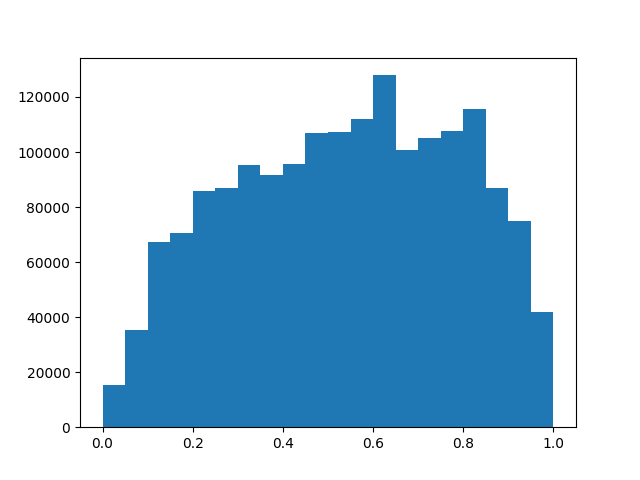

In [10]:

df = nubb_1bar
filt_evid = pd.read_csv("../eventlists/truestudy/ATPC_0nubb_1bar_5percent.csv")
df_filt = df[df.event_id.isin(filt_evid.event_id.values)]

plt.figure()
# n_gen, bins, _ = plt.hist( GetZPos(df, shifts[0]), bins = np.arange(0,1.05,0.05));
n_gen, bins, _ = plt.hist( GetZPos(df_filt, shifts[0]), bins = np.arange(0,1.05,0.05));
# n_sel, _ , _   = plt.hist( df_filt[df_filt.particle_id == 2].final_z);
# efficiency, error = CalcEfficiency(n_sel, n_gen)
# bin_centers = bins+0.025/2.0
# bin_centers = bin_centers[:-1]


In [11]:
nubb_1bar_highstats = LoadFiles(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_0nubb/1bar/nexus/*.h5")
# 21 mins to run


0 / 4208
500 / 4208
1000 / 4208
1500 / 4208
2000 / 4208
2500 / 4208
3000 / 4208
3500 / 4208
4000 / 4208


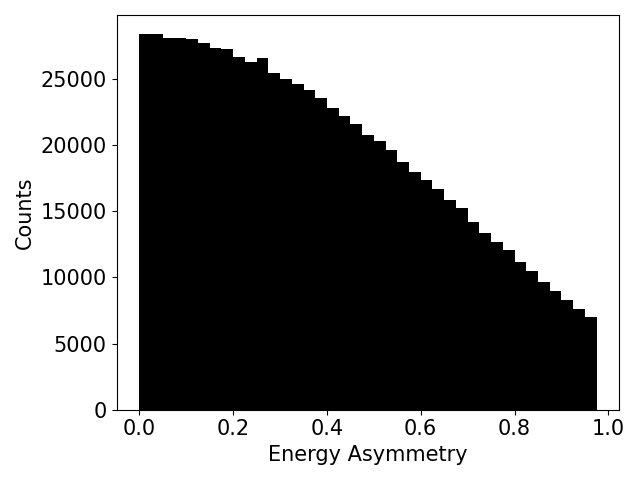

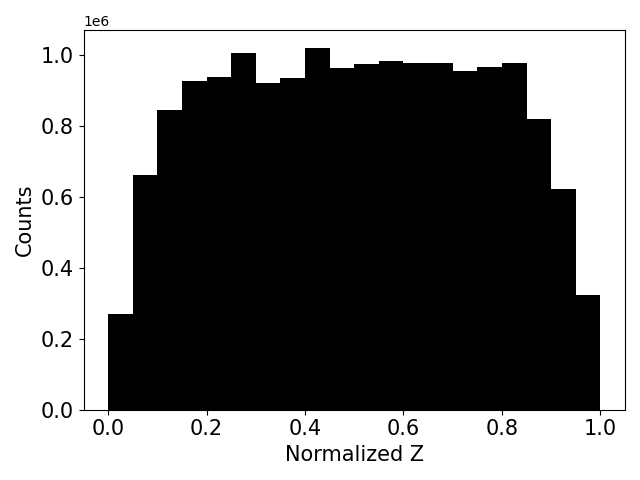

In [12]:
# display(nubb)

plt.figure()

n_gen, bins, _ = plt.hist( CalcAssymetry(nubb_1bar_highstats), bins = np.arange(0,1,0.025),color = "k");
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.tight_layout()

plt.figure()
n_gen, bins, _ = plt.hist( GetZPos(nubb_1bar_highstats, shifts[0]), bins = np.arange(0,1.05,0.05),color = "k");
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.tight_layout()

Correcting Efficiency by factor  0.532
Correcting Efficiency by factor  0.532


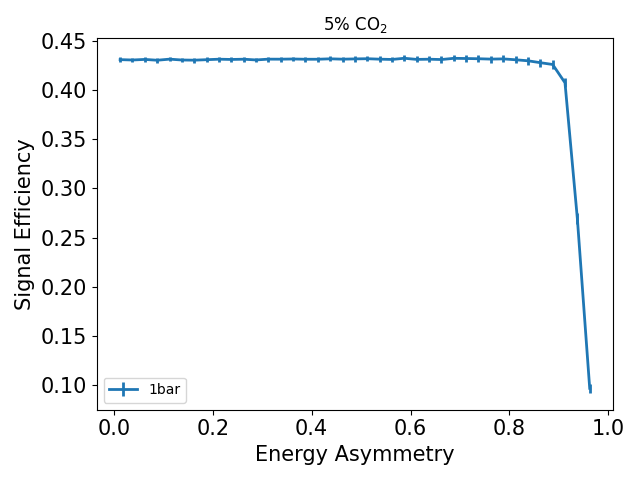

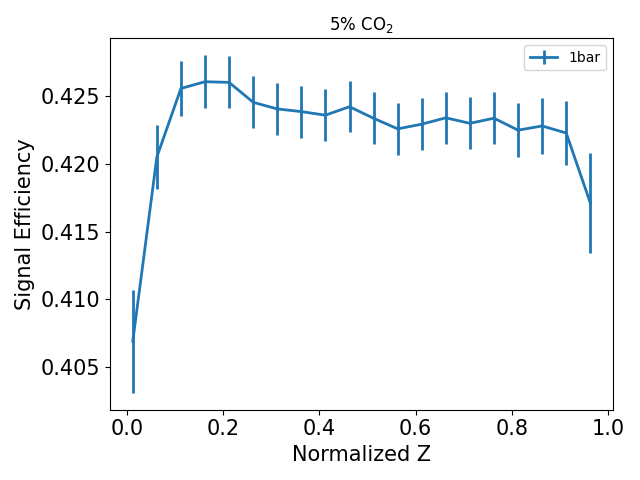

In [13]:
nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetAsymmetryHistogram(nubb_1bar_highstats, "../eventlists/ATPC_1bar_5percent_highstats.csv", 1)

plt.figure()
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetZPosHistogram(nubb_1bar_highstats, "../eventlists/ATPC_1bar_5percent_highstats.csv", shifts[0], 1)

plt.figure()
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()